# 更好的手动特征工程
虽然featuretools提供了自动特征工程，但是dfs巨慢，这让人头疼。

这促使我寻找更好的自动或者手动方式。


参考Feature Selection with Null Importances
- 有效特征面对假标签表现得应该很差
- 无效特征面对真假标签表现得差不多

[手动特征工程](https://www.kaggle.com/code/ogrellier/lighgbm-with-selected-features/script)

我们可以用将标签不断打散，每次lgbm计算特征，就可以识别出无效特征了

以apptrain开始

In [ ]:
import pandas as pd 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import lightgbm as lgb
from lightgbm import LGBMClassifier
import warnings
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import KFold,StratifiedKFold
import re

gc.enable()
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False 
plt.rcParams['figure.figsize'] = (8,6) 
plt.rcParams['figure.dpi'] = 100

In [ ]:
application_train = pd.read_csv('data/application_train.csv')
application_test = pd.read_csv('data/application_test.csv')

In [ ]:
train_labels = application_train['TARGET']
train_ids = application_train['SK_ID_CURR']
test_ids = application_test['SK_ID_CURR']
train_features = application_train.drop(columns=['TARGET', 'SK_ID_CURR'])
test_features = application_test.drop(columns=['SK_ID_CURR'])

In [ ]:
for col in train_features.select_dtypes(include=['object']).columns:
    train_features[col] = train_features[col].astype('category')

for col in test_features.select_dtypes(include=['object']).columns:
    test_features[col] = test_features[col].astype('category')

## null importance

In [ ]:
def get_features_importance(train_features, train_labels):
    lgbm_model = LGBMClassifier(
        n_estimators=100,      
        learning_rate=0.1, 
        max_depth=8,      
        random_state=42,   
    )
    lgbm_model.fit(train_features, train_labels)
    features_importance = pd.DataFrame(
        {
            'gain': lgbm_model.booster_.feature_importance(importance_type='gain'),
            'split': lgbm_model.booster_.feature_importance(importance_type='split'),
            'feature': lgbm_model.feature_name_
        }
    )
    return features_importance

In [ ]:
actual_fi_df = get_features_importance(train_features, train_labels)

多次shuffle
- pd没有这个函数， 使用`.sample(frac=1)` 全采样
  - 这个服从正太分布采用

In [ ]:
runs = 50
fi_list = []
for i in range(runs):
    shuffle_train_labels = train_labels.sample(frac=1)
    fi_df = get_features_importance(train_features, shuffle_train_labels)
    fi_df['run'] = i + 1
    fi_list.append(fi_df)

In [ ]:
fi_dfs = pd.concat(fi_list, axis=0, ignore_index=True)

我们可以绘制 这些重要性得分布，
- 如果真实重要性与随机重要性相近，那就是假特征

In [ ]:
actual_fi_df.sort_values(by='gain')

In [ ]:
def plot_importance_distribution_of_feature(actual_fi_df, df, feature_name):
    data = df[df['feature'] == feature_name]
    
    actual_gain = actual_fi_df.loc[actual_fi_df['feature'] == feature_name, 'gain'].iloc[0]
    actual_split = actual_fi_df.loc[actual_fi_df['feature'] == feature_name, 'split'].iloc[0]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    
    sns.histplot(data['gain'], alpha=0.3, label='Null Gain', ax=ax1, kde=True)
    ax1.axvline(x=actual_gain,  linestyle='--', label=f'Actual: {actual_gain:.1f}')
    ax1.set_title(f'Gain Importance: {feature_name}')
    ax1.legend()
    
    sns.histplot(data['split'],  alpha=0.3, label='Null Split', ax=ax2, kde=True)
    ax2.axvline(x=actual_split,  linestyle='--', label=f'Actual: {actual_split}')
    ax2.set_title(f'Split Importance: {feature_name}')
    ax2.legend()
    
    plt.tight_layout()


In [ ]:
plot_importance_distribution_of_feature(actual_fi_df, fi_dfs, 'FONDKAPREMONT_MODE')

In [ ]:
plot_importance_distribution_of_feature(actual_fi_df, fi_dfs, 'EXT_SOURCE_3')

我们以分布得75分位数 作为 分布值， 去与真实对比。
- 如果大于这个值，表示真实特征表现优于75%的噪声
  - 即 score>0 。 我们使用log以0分界，可以更好的剔除

In [ ]:
def get_feature_score(actual_importance, shuffle_importances, feature_name):
    feature_actual_gain = actual_importance[actual_importance['feature'] == feature_name]['gain']
    feature_actual_split = actual_importance[actual_importance['feature'] == feature_name]['split']
    feature_shuffle_gains = shuffle_importances[shuffle_importances['feature'] == feature_name]['gain']
    feature_shuffle_splits = shuffle_importances[shuffle_importances['feature'] == feature_name]['split']
    return pd.DataFrame({
        'feature': feature_name,
        'gain_score':  np.log(1e-10 + feature_actual_gain / np.percentile(feature_shuffle_gains, 75)),
        'split_score': np.log(1e-10 + feature_actual_split / np.percentile(feature_shuffle_splits, 75)),
    })

In [ ]:
get_feature_score(actual_fi_df, fi_dfs, 'CODE_GENDER')

In [ ]:
features_score = []
for f in actual_fi_df['feature'].unique():
    features_score.append(get_feature_score(actual_fi_df, fi_dfs, f))

In [ ]:
features_score = pd.concat(features_score, ignore_index=True)

In [ ]:
plot_gain_features_score = features_score.sort_values(by='gain_score', ascending=False)
plot_split_features_score = features_score.sort_values(by='split_score', ascending=False)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

sns.barplot(data=plot_gain_features_score.head(70), x='gain_score', y='feature', ax=axes[0])
axes[0].set_title('Top 70 Features by Gain')

sns.barplot(data=plot_split_features_score.head(70), x='split_score', y='feature', ax=axes[1])
axes[1].set_title('Top 70 Features by Split')

plt.tight_layout()

In [ ]:
features_score.head()

In [ ]:
threshold = 30
features_removed_by_gain_score = features_score[features_score['gain_score'] < 0]
features_removed_by_split_score = features_score[features_score['split_score'] < 0]
features_removed = set(features_removed_by_gain_score['feature']) & set(features_removed_by_split_score['feature'])

In [ ]:
features_removed

In [ ]:
train_features_clean = train_features.drop(columns=features_removed)
test_features_clean = test_features.drop(columns=features_removed)

In [ ]:
lgbm_model = LGBMClassifier(
    n_estimators=100,      
    learning_rate=0.1, 
    max_depth=8,      
    random_state=42,   
)
lgbm_model.fit(train_features_clean, train_labels)

In [ ]:
train_pred = lgbm_model.predict_proba(train_features_clean)
roc_auc_score(train_labels, train_pred[:, 1])

In [ ]:
import time
import os

def submit(ids, pred, name, feature_count=None):
    """
    ids: 测试集的 SK_ID_CURR
    pred: 模型预测概率
    name: 你的实验备注 (如 'lgb_v1', 'baseline')
    feature_count: 可选，记录模型使用了多少个特征
    """
    # 1. 创建提交 DataFrame
    submit_df = pd.DataFrame({
        'SK_ID_CURR': ids,
        'TARGET': pred
    })

    # 2. 生成时间戳 (格式: 0213_1530)
    timestamp = time.strftime("%m%d_%H%M")
    
    # 3. 构造文件名
    # 格式: 0213_1530_lgb_v1_f542.csv
    f_str = f"_f{feature_count}" if feature_count else ""
    filename = f"{timestamp}_{name}{f_str}.csv"
    
    # 4. 确保保存目录存在 (可选)
    if not os.path.exists('submissions'):
        os.makedirs('submissions')
    
    save_path = os.path.join('submissions', filename)
    
    # 5. 保存并打印提示
    submit_df.to_csv(save_path, index=False)
    
    return submit_df


## 手动特征工程
相比之前手动特征工程，我们会构造更多的领域特征

In [2]:
def onehot_encoder(df, nan_as_category=True):
    """ 
    df: 输入的 DataFrame
    nan_as_category: 是否将 NaN 视为一个独立的类别进行编码
    """
    original_columns = df.columns.tolist()
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
    df = pd.get_dummies(df, columns=categorical_cols, dummy_na=nan_as_category)
    new_columns = [col for col in df.columns if col not in original_columns]
    return df, new_columns

kfold将数据分为几份，每次用其中一份做验证，其他做训练。得到更稳定结果
- stratified=True 代表分层抽样，保持每份数据中正负样本比例相同

In [4]:
import time
import os

def submit(ids, pred, name, feature_count=None):
    """
    ids: 测试集的 SK_ID_CURR
    pred: 模型预测概率
    name: 你的实验备注 (如 'lgb_v1', 'baseline')
    feature_count: 可选，记录模型使用了多少个特征
    """
    # 1. 创建提交 DataFrame
    submit_df = pd.DataFrame({
        'SK_ID_CURR': ids,
        'TARGET': pred
    })

    # 2. 生成时间戳 (格式: 0213_1530)
    timestamp = time.strftime("%m%d_%H%M")
    
    # 3. 构造文件名
    # 格式: 0213_1530_lgb_v1_f542.csv
    f_str = f"_f{feature_count}" if feature_count else ""
    filename = f"{timestamp}_{name}{f_str}.csv"
    
    # 4. 确保保存目录存在 (可选)
    if not os.path.exists('submissions'):
        os.makedirs('submissions')
    
    save_path = os.path.join('submissions', filename)
    
    # 5. 保存并打印提示
    submit_df.to_csv(save_path, index=False)
    
    return submit_df


In [15]:
def kfold_lightgbm(df, num_folds, stratified=False, debug=True):
    def clean_names(df):
        # 替换所有非字母、数字的字符为下划线
        # 这里的正则 [^A-Za-z0-9_] 会匹配空格、斜杠、括号等所有特殊字符
        df.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', col) for col in df.columns]
        # 顺便处理一下可能出现的重复下划线，比如 __
        df.columns = [re.sub(r'_+', '_', col).strip('_') for col in df.columns]
        return df
    df = clean_names(df)
    
    train_df = df[df['TARGET'].notnull()]
    test_df = df[df['TARGET'].isnull()]
    if stratified:
        fold = StratifiedKFold(n_splits=num_folds, shuffle=True)
    else:
        fold = KFold(n_splits=num_folds, shuffle=True)

    features = [f for f in train_df.columns if f not in ['TARGET','SK_ID_CURR','SK_ID_BUREAU','SK_ID_PREV','index']]
    feature_importance_df = pd.DataFrame()
    out_of_fold_preds = np.zeros(train_df.shape[0])
    submit_preds = np.zeros(test_df.shape[0])
    for n_fold, (train_idx, valid_idx) in enumerate(fold.split(train_df[features], train_df['TARGET'])):
        dtrain = lgb.Dataset(data=train_df[features].iloc[train_idx],
            label = train_df['TARGET'].iloc[train_idx],
            free_raw_data=False
        )
        dvalid = lgb.Dataset(data=train_df[features].iloc[valid_idx],
            label = train_df['TARGET'].iloc[valid_idx],
            free_raw_data=False
        )
        params = {
            'objective': 'binary',
            'metric': 'auc',
            'max_depth': 8,
            'num_leaves': 20,
            'learning_rate': 0.02,
        }
        clf = lgb.train(
            params = params,
            train_set=dtrain,
            valid_sets=[dtrain, dvalid],
            num_boost_round=1000,
        )
        out_of_fold_preds[valid_idx] = clf.predict(dvalid.data)
        submit_preds += clf.predict(test_df[features]) / fold.n_splits

        fold_importance_df = pd.DataFrame()
        fold_importance_df["feature"] = features
        fold_importance_df["importance"] = clf.feature_importance(importance_type='gain')
        fold_importance_df["fold"] = n_fold + 1
        feature_importance_df = pd.concat([feature_importance_df, fold_importance_df], axis=0)
        print('Fold %2d AUC : %.6f' % (n_fold + 1, roc_auc_score(dvalid.label, out_of_fold_preds[valid_idx])))
        del clf, dtrain, dvalid
        gc.collect()


    if not debug:
        submit(test_df['SK_ID_CURR'], submit_preds, 'lgbm_folds', feature_count=len(features))

    print('Full AUC score %.6f' % roc_auc_score(train_df['TARGET'], out_of_fold_preds))
    return feature_importance_df


In [6]:
def plot_importances(feature_importance_df):
    cols = feature_importance_df[["feature", "importance"]].groupby("feature").mean().sort_values(by="importance", ascending=False)[:30].index
    best_features = feature_importance_df.loc[feature_importance_df.feature.isin(cols)]
    plt.figure(figsize=(8, 10))
    sns.barplot(x="importance", y="feature", data=best_features.sort_values(by="importance", ascending=False))
    plt.title('LightGBM Features (avg over folds)')
    plt.tight_layout()


### application_train/test

In [ ]:
nrows = None
app_train = pd.read_csv('data/application_train.csv', nrows=nrows)
app_test = pd.read_csv('data/application_test.csv', nrows=nrows)
print(f'train {len(app_train)}, test {len(app_test)}')
app = pd.concat([app_train, app_test])
app = app.reset_index()
print(f'app {len(app)}')

#### 函数

In [7]:
def application_train_test():
    """ 
    1. 异常数据处理
    2. 增加一些特征
    """
    nrows = None
    app_train = pd.read_csv('data/application_train.csv', nrows=nrows)
    app_test = pd.read_csv('data/application_test.csv', nrows=nrows)
    print(f'train {len(app_train)}, test {len(app_test)}')
    app = pd.concat([app_train, app_test])
    app = app.reset_index()
    print(f'app {len(app)}')

    # 
    app['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)

    app['NEW_CREDIT_TO_ANNUITY_RATIO'] = app['AMT_CREDIT'] / (app['AMT_ANNUITY'] + 1)
    app['NEW_CREDIT_TO_GOODS_RATIO'] = app['AMT_CREDIT'] / (app['AMT_GOODS_PRICE'] + 1)
    app['NEW_EMPLOYED_TO_BIRTH_RATIO'] = app['DAYS_EMPLOYED'] / (app['DAYS_BIRTH'] + 1)
    app['NEW_ANNITY_TO_INCOME_RATIO'] = app['AMT_ANNUITY'] / (app['AMT_INCOME_TOTAL'] + 1)
    app['NEW_CREDIT_TO_INCOME_RATIO'] = app['AMT_CREDIT'] / (app['AMT_INCOME_TOTAL'] + 1)
    app['NEW_EXT_SOURCE_PROD'] = app['EXT_SOURCE_1'] * app['EXT_SOURCE_2'] * app['EXT_SOURCE_3']
    app['NEW_EXT_SOURCE_MEAN'] = app[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)
    app['NEW_EXT_SOURCE_STD'] = app[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].std(axis=1)

    for bin_feature in ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CODE_GENDER']:
        app[bin_feature], uniques = pd.factorize(app[bin_feature])
    app, new_cat_features = onehot_encoder(app)
    del app_train, app_test
    gc.collect()
    print(f'app: {app.shape}')
    return app
    

In [8]:
app = application_train_test()

train 307511, test 48744
app 356255
app: (356255, 264)


In [16]:
features_importance_df = kfold_lightgbm(app, num_folds=5, debug=False)

[LightGBM] [Info] Number of positive: 19856, number of negative: 226152
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.078917 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13524
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 244
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080713 -> initscore=-2.432701
[LightGBM] [Info] Start training from score -2.432701
Fold  1 AUC : 0.767032
[LightGBM] [Info] Number of positive: 19813, number of negative: 226196
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.210227 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13534
[LightGBM] [Info] Number of data points in the train set: 246009, number of used features: 244
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080538 -> initscore=-2.435064
[LightGBM] [Info] Start training fr

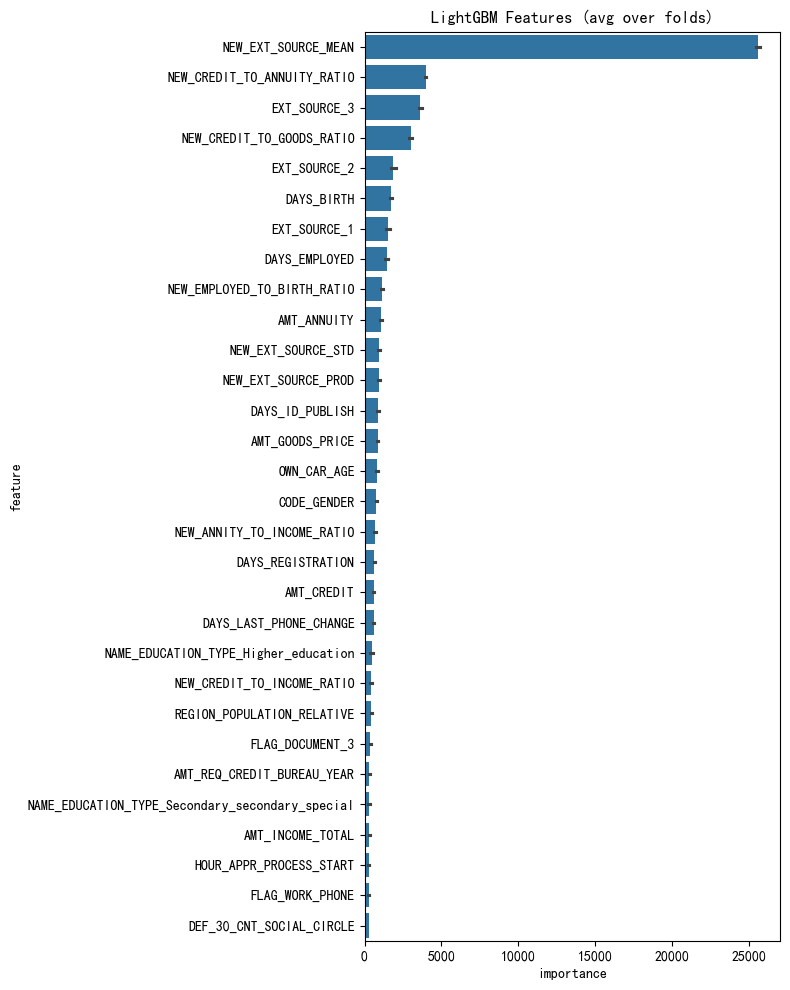

In [14]:
plot_importances(features_importance_df)

构建新特征才是提分的核心！

#### 个人信息

In [ ]:
def plot_category_stat(data, feature, target='TARGET'):
    """ 分类特征 计数、违约率、缺失值多少， 双轴图
    可以看到长尾
    """
    temp_data = data[[feature, target]].copy()

    percent = temp_data[feature].isnull().mean() * 100
    print(f'>>> {feature} has {percent:.2f}% missing values!')

    fig, ax1 = plt.subplots(figsize=(10, 6))

    # 按照计数从高到低
    sns.countplot(x=feature, data=temp_data, ax=ax1, color='lightgray', alpha=0.5,        )
    ax1.set_ylabel('样本总数 (Count)', fontsize=12)
    ax1.set_title(f'{feature} 的数量与违约率综合分析', fontsize=15)

    ax2 = ax1.twinx()
    sns.pointplot(x=feature, y=target, data=temp_data, ax=ax2, color='red',)
    ax2.set_ylabel('平均违约率 (Target Mean)', color='red', fontsize=12)
    
    plt.tight_layout()
    plt.show()

##### CODE_GENDER

概率柱状图。
- 高度表示， 违约人数/总人数。 

In [ ]:
sns.barplot(data=app, x='CODE_GENDER',y='TARGET')

In [ ]:
app = app[app['CODE_GENDER'] != 'XNA']
print(app.shape)

##### DAYS_BIRTH
- 岁数分组

In [ ]:
min_age, max_age = (app['DAYS_BIRTH'] / -365).min(), (app['DAYS_BIRTH'] / -365).max()
print(f'birth min age:{min_age}, max age: {max_age}')

In [ ]:
app['NEW_AGE_BIN']= pd.cut(app['DAYS_BIRTH'] / -365, bins=np.linspace(20, 70, 11))

In [ ]:
sns.barplot(data=app, x= 'NEW_AGE_BIN', y = 'TARGET')
plt.title('各年龄段的违约率')
plt.tight_layout()

随着年龄增加，违约率逐渐降低

##### DAYS_REGISTRATION
- 户口本更新时间
- 更新时间离得越远，人越稳定
- 与年龄 比率，  比例越大越稳定
- 着重标识最近一年修改的

In [ ]:
app['NEW_YEARS_REGISTRATION'] = app['DAYS_REGISTRATION'] / -365

In [ ]:
app['NEW_REGISTRATION_TO_AGE_RATIO'] = app['DAYS_REGISTRATION'] / app['DAYS_BIRTH']

In [ ]:
sns.kdeplot(data=app, x='NEW_REGISTRATION_TO_AGE_RATIO', hue='TARGET', common_norm = False)

最近一年内更新户口居住地址

In [ ]:
app['FLAG_1year_RECENT_REGISTRATION_CHANGE'] = (app['DAYS_REGISTRATION'] > -365).astype(int)

In [ ]:
sns.barplot(data=app, x='FLAG_1year_RECENT_REGISTRATION_CHANGE', y='TARGET')
plt.title('最近一年更新居住地址')

最近更新户口居住地址的人可能违约概率大。

In [ ]:
app['RECENT_3month_REGISTRATION_CHANGE'] = (app['DAYS_REGISTRATION'] > -31).astype(int)

In [ ]:
sns.barplot(data=app, x='RECENT_3month_REGISTRATION_CHANGE', y='TARGET')
plt.title('最近3个月更新居住地址')

##### DAYS_ID_PUBLISH

和DAYS_REGISTRATION强相关嘛？

In [ ]:
app[['DAYS_ID_PUBLISH', 'DAYS_BIRTH']].corr()

相关性不强，我们需要单独处理

In [ ]:
app['YEAR_ID_PUBLISH'] = app['DAYS_ID_PUBLISH']/-365
sns.kdeplot(data = app, x='YEAR_ID_PUBLISH', hue='TARGET', common_norm=False)
plt.title('身份证更新年限')

我们构造一个新特征，标识

In [ ]:
app['DAYS_DIFF_ID_REG'] = app['DAYS_ID_PUBLISH'] - app['DAYS_REGISTRATION']
sns.kdeplot(data = app, x = 'DAYS_DIFF_ID_REG', hue='TARGET', common_norm=False)
plt.title('身份证更新与居住地更新差值')

##### DAYS_LAST_PHONE_CHANGE

In [ ]:
app['PHONE_CHANGE_DAYS'] = app['DAYS_LAST_PHONE_CHANGE'].abs()

In [ ]:
app['PHONE_CHANGE_BIN'] = pd.cut(app['PHONE_CHANGE_DAYS'], bins=[0, 10, 30, 60, 180, 365, 730, 1095, 4000])

In [ ]:
plot_category_stat(app, 'PHONE_CHANGE_BIN')

我们可以看到哪些最近更新手机号的人，确实往往具有更高的违约率.


##### FLAG_MOBIL，FLAG_EMP_PHONE，FLAG_WORK_PHONE，FLAG_CONT_MOBILE，FLAG_PHONE，FLAG_EMAIL

1. 我们可以将这个联系方式组合为一个特征。组合时候应该有权重
2. 一个人必须有FLAG_MOBIL

In [ ]:
app['CONTACT_SCORE'] = app['FLAG_EMAIL'] + app['FLAG_WORK_PHONE']  + app['FLAG_PHONE'] * 1 + app['FLAG_CONT_MOBILE'] + app['FLAG_EMP_PHONE'] 

In [ ]:
fig, axes = plt.subplots(3,2, figsize=(9,10), sharex=True, sharey = True)
axes = axes.flatten()
contact_cols =  ['FLAG_EMAIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 
                'FLAG_CONT_MOBILE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE']
for i,col in enumerate(contact_cols):
    sns.barplot(data=app, x=col, y='TARGET', ax=axes[i])
    axes[i].set_title(f'Target Mean by {col}')
    axes[i].set_ylim(0, 0.12) # 统一 y 轴刻度，方便横向对比“谁的柱子更高

In [ ]:
plt.figure(figsize=(6,4))
sns.kdeplot(data=app, x='CONTACT_SCORE', hue = 'TARGET', common_norm=False)


这些特征都没有用，都不需要。组合起来也看不出什么。

##### NAME_EDUCATION_TYPE

In [ ]:
plot_category_stat(app, 'NAME_EDUCATION_TYPE')

1. 具有长尾。
2. 初中学历作为最低学历，却具备最大违约率； 博士学位作为最高学历，具备最低违约率；
3. 这是一个**有序**的特征，显然，学历越高违约率越低

In [ ]:
app['NAME_EDUCATION_TYPE'].value_counts()

In [ ]:
app['NAME_EDUCATION_TYPE'] = app['NAME_EDUCATION_TYPE'].map({
    'Lower secondary': 1,
    'Secondary / secondary special': 2,
    'Incomplete higher': 3,
    'Higher education': 4,
    'Academic degree': 5
})
app['EDUCATION_ORDINAL'] = app['NAME_EDUCATION_TYPE'].fillna(0)

#### 车

In [ ]:
plot_category_stat(app, 'FLAG_OWN_CAR')

有车的违约率更低

In [ ]:
app['NEW_FLAG_OWN_CAR'] = app['FLAG_OWN_CAR'].map({
    'N': 0,
    'Y': 1,
})

In [ ]:
app['NEW_FLAG_OWN_CAR'].value_counts()

In [ ]:
sns.kdeplot(data=app, x='OWN_CAR_AGE', hue='TARGET', common_norm=False)

看起来没什么区别， 但是右边的长尾效应和异常值 把左边压扁了

In [ ]:
sns.histplot(data=app, x='OWN_CAR_AGE')

1. 老爷车60-90年算异常数据嘛？
- 不能，因为显然具有特征意义。
- 一方面，拿出一个新特征，来标识； 另一方面，通过clip到35年，去掉长尾效应

In [ ]:
app['INTER_OWN_CAR_AGE'] = app['OWN_CAR_AGE'].clip(upper=35)
app['NEW_IS_OLD_CAR'] = app['OWN_CAR_AGE'] > 60

In [ ]:
app['NEW_CAR_AGE_BIN'] = pd.cut(app['INTER_OWN_CAR_AGE'], bins=[0, 1, 3, 5, 7, 10, 15,20, 35])

In [ ]:
plot_category_stat(app, 'NEW_CAR_AGE_BIN')

- 总体来说，汽车年限越高， 违约率越高.
- 刚买3年内的车，违约率也会高点

#### 房屋评价得分
- 对于房屋详细的特征，他们不重要。我们不要一个个处理！
1. 尝试构建房屋评分
2. 只采用mode
3. 挑几个关键特征

##### FLAG_OWN_REALTY

In [ ]:
plot_category_stat(app, 'FLAG_OWN_REALTY')

- 就是没房的违约率更高

##### TOTALAREA_MODE

In [ ]:
sns.kdeplot(data=app, x='TOTALAREA_MODE', hue='TARGET', common_norm=False)

#### 地区住址
- 通过求和描述一个人 居住地 工作地 老家 的稳定性

In [ ]:
app['INTER_LOCATION_INCONSISTENT_COUNT'] = (app['REG_CITY_NOT_LIVE_CITY'] + 
                                          app['REG_CITY_NOT_WORK_CITY'] + 
                                          app['LIVE_CITY_NOT_WORK_CITY'] + 
                                          app['REG_REGION_NOT_LIVE_REGION']+
                                          app['REG_REGION_NOT_WORK_REGION'] +
                                          app['LIVE_REGION_NOT_WORK_REGION']
                                          )

In [ ]:
plot_category_stat(app, 'INTER_LOCATION_INCONSISTENT_COUNT')

- 那些非0的值，往往确实更加具备更高违约率

In [ ]:
app['INTER_REGION_POPULATION_BIN'] = pd.cut(app['REGION_POPULATION_RELATIVE'], bins=10)

In [ ]:
plot_category_stat(app, 'INTER_REGION_POPULATION_BIN')

- 依然是通过bin分桶，能够看到局部之间的下降趋势。地区密度越大（大城市），违约率越低。

对于地区和城市评级，我们通过diff构造

In [ ]:
app['INTER_REGION_RATING_DIFF'] = app['REGION_RATING_CLIENT_W_CITY'] - app['REGION_RATING_CLIENT']

In [ ]:
plot_category_stat(app, 'INTER_REGION_RATING_DIFF')

- 分类数过少。极度不平均
- 极端的类并未展示出极端的违约率。
不采用

#### 社交圈

In [ ]:
app[['OBS_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE']].corr()

- 相关性太高了。我们只采用60天的数据
- "近朱者赤，近墨者黑"， DEF逾期人数更加重要
- 我们假设这个人有100人朋友圈，DEF/OBS表示 这个朋友圈坏账率

In [ ]:
app['OBS_60_CNT_SOCIAL_CIRCLE'].hist()

clip去掉长尾噪声，

In [ ]:
app['OBS_60_CNT_SOCIAL_CIRCLE'] = app['OBS_60_CNT_SOCIAL_CIRCLE'].clip(upper=12)

In [ ]:
app['OBS_60_CNT_SOCIAL_CIRCLE'].hist()

In [ ]:
app['DEF_60_CNT_SOCIAL_CIRCLE']= app['DEF_60_CNT_SOCIAL_CIRCLE'].clip(upper=5)

In [ ]:
app['DEF_60_CNT_SOCIAL_CIRCLE'].hist()

In [ ]:
app['DEF_60_CNT_SOCIAL_CIRCLE'] = app['DEF_60_CNT_SOCIAL_CIRCLE'].fillna(0)
app['OBS_60_CNT_SOCIAL_CIRCLE'] = app['OBS_60_CNT_SOCIAL_CIRCLE'].fillna(0)

In [ ]:
app['NEW_SOCIAL_RATIO_60'] = app['DEF_60_CNT_SOCIAL_CIRCLE']/(app['OBS_60_CNT_SOCIAL_CIRCLE'] + 1e-10)

In [ ]:
app['NEW_SOCIAL_RATIO_60'].isnull().sum()

In [ ]:
app['NEW_SOCIAL_BIN'] = pd.cut(app['NEW_SOCIAL_RATIO_60'], bins=[-0.1, 0.1,1, np.inf])

In [ ]:
plot_category_stat(app, 'NEW_SOCIAL_BIN')

- 或许是有用的，这些少数的数据有着很高的违约率

#### 家庭

In [ ]:
plot_category_stat(app, 'NAME_FAMILY_STATUS')

- 同居和单身的违约率比较高

In [ ]:
app[['CNT_FAM_MEMBERS', 'CNT_CHILDREN']].corr()

高度相关，保留一个

In [ ]:
plot_category_stat(app, 'CNT_CHILDREN')

In [ ]:
app['CNT_CHILDREN'].value_counts(normalize=True)

In [ ]:
app['NEW_FAM_CNT'] = app['CNT_CHILDREN'].clip(upper=3)

In [ ]:
plot_category_stat(app, 'NEW_FAM_CNT')


#### 财务能力
- 负债收入比

In [ ]:
app['AMT_INCOME_TOTAL'].sort_values()

In [ ]:
app['AMT_INCOME_TOTAL'].hist()

In [ ]:
app['AMT_ANNUITY'].hist()

In [ ]:
app['NEW_ANNUITY_INCOME_RATIO'] = app['AMT_ANNUITY']/app['AMT_INCOME_TOTAL']
app['NEW_ANNUITY_INCOME_RATIO_BIN'] = pd.cut(app['NEW_ANNUITY_INCOME_RATIO'], bins=[-0.1, 0.1, 0.2, 0.3, 0.5, 2])

In [ ]:
plot_category_stat(app,'NEW_ANNUITY_INCOME_RATIO_BIN' )

In [ ]:
app[['AMT_ANNUITY','AMT_CREDIT']].corr()

In [ ]:
app['INTER_CREDIT_TO_ANNUITY']=app['AMT_CREDIT']/app['AMT_ANNUITY']
sns.kdeplot(data=app, x='INTER_CREDIT_TO_ANNUITY', hue='TARGET', common_norm=False)

- 近似于贷款期数

---

In [ ]:
app['AMT_GOODS_PRICE'].isnull().sum()

In [ ]:
app['NEW_CREDIT_TO_GOODS_RATIO'] = app['AMT_CREDIT'] / app['AMT_GOODS_PRICE']

In [ ]:
sns.kdeplot(data=app, x='NEW_CREDIT_TO_GOODS_RATIO', hue='TARGET', common_norm=False)

In [ ]:
app['NEW_CREDIT_TO_GOODS_RATIO_BIN'] = pd.cut(app['NEW_CREDIT_TO_GOODS_RATIO'], bins=[-0.1, 1, 1.3, 1.5 ,1.8, 2,np.inf])
plot_category_stat(app, 'NEW_CREDIT_TO_GOODS_RATIO_BIN')

---

In [ ]:
app['NAME_INCOME_TYPE'].value_counts()

太少了，不具备特征意义

In [ ]:
plot_category_stat(app, 'NAME_INCOME_TYPE')

---

In [ ]:
app['NAME_HOUSING_TYPE'].value_counts()

In [ ]:
plot_category_stat(app,'NAME_HOUSING_TYPE')

那些没有住房的人虽少，但违约率高，具有特征意义

#### 外部信用评分

In [ ]:
app[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].isnull().sum() / len(app)

缺失值过多。 但具有意义。表示没有过信用记录。我们必须看重它。

In [ ]:
app['NEW_EXT_SOURCE_MISSING_CNT'] = app[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].isnull().sum(axis=1)

In [ ]:
app['NEW_EXT_SOURCE_MISSING_CNT'].value_counts()

In [ ]:
plot_category_stat(app, 'NEW_EXT_SOURCE_MISSING_CNT')

可以看到，确实信用评分缺失更多的人，违约率会更高

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    sns.kdeplot(data=app, x=col, hue='TARGET', common_norm=False, ax=axes[i])
    axes[i].set_title(f'{col} Distribution by Target')

不出所料，这三个外部信用评分确实具有很好的区分能力。

---

In [ ]:
app['AMT_REQ_CREDIT_BUREAU_HOUR'].fillna(0, inplace=True)
app['AMT_REQ_CREDIT_BUREAU_WEEK'].fillna(0, inplace=True)
app['AMT_REQ_CREDIT_BUREAU_DAY'].fillna(0, inplace=True)
app['AMT_REQ_CREDIT_BUREAU_MON'].fillna(0, inplace=True)
app['AMT_REQ_CREDIT_BUREAU_QRT'].fillna(0, inplace=True)
app['AMT_REQ_CREDIT_BUREAU_YEAR'].fillna(0, inplace=True)

查看一年内查询贷款次数

In [ ]:
app['AMT_REQ_CREDIT_BUREAU_YEAR'] = app['AMT_REQ_CREDIT_BUREAU_YEAR'].clip(upper=10)

In [ ]:
plot_category_stat(app, 'AMT_REQ_CREDIT_BUREAU_YEAR')

最近一周查询比率

In [ ]:
app['NEW_REQ_WEEK_TO_YEAR_RATIO'] = app['AMT_REQ_CREDIT_BUREAU_WEEK'] / (app['AMT_REQ_CREDIT_BUREAU_YEAR'] + 1e-10)
app['NEW_REQ_WEEK_TO_YEAR_RATIO_BIN'] = pd.cut(app['NEW_REQ_WEEK_TO_YEAR_RATIO'], bins=[-0.1, 0.1, 0.5, 1, 2, np.inf])

In [ ]:
plot_category_stat(app, 'NEW_REQ_WEEK_TO_YEAR_RATIO_BIN')

似乎是没什么区分性

#### 工作情况

In [ ]:
app['DAYS_EMPLOYED'].isnull().sum()

In [ ]:
sns.kdeplot(data=app, x='DAYS_EMPLOYED', hue='TARGET', common_norm=False)

In [ ]:
app[app['DAYS_EMPLOYED'] > 300000]['DAYS_EMPLOYED'].value_counts()

In [ ]:
app['DAYS_EMPLOYED'] = app['DAYS_EMPLOYED'].replace(365243, np.nan)
app['DAYS_EMPLOYED'] = app['DAYS_EMPLOYED'].fillna(app['DAYS_EMPLOYED'].median())

In [ ]:
app['YEARS_EMPLOYED'] = (app['DAYS_EMPLOYED'] / -365).astype(int)

In [ ]:
sns.kdeplot(data=app, x='YEARS_EMPLOYED', hue='TARGET', common_norm=False)

In [ ]:
app['YEARS_EMPLOYED_BIN'] = pd.cut(app['YEARS_EMPLOYED'], bins=[0, 2, 5, 10, 20, 100])

In [ ]:
plot_category_stat(app, 'YEARS_EMPLOYED_BIN')

可以看到，随着工作年限增加，违约率逐渐降低

---

In [ ]:
plot_category_stat(app, 'NAME_INCOME_TYPE')

那些没动作的人，确实违约率更高

---

In [ ]:
(app['ORGANIZATION_TYPE'].value_counts() / len(app) * 100).sort_values(ascending=False)

```{warning} 
类别很多，我们要防止Onehot维度爆炸。 树模型分裂过多
可以使用LabelEncoding

In [ ]:
plot_category_stat(app, 'ORGANIZATION_TYPE')

#### 申请行为

In [ ]:
plot_category_stat(app, 'NAME_CONTRACT_TYPE')

有着明显的区分

---

In [ ]:
plot_category_stat(app, 'NAME_TYPE_SUITE')

带着家庭和孩子的违约率更低

---

In [ ]:
plot_category_stat(app, 'WEEKDAY_APPR_PROCESS_START')

区别不太大

---

In [ ]:
app['HOUR_APPR_PROCESS_START'].value_counts()

In [ ]:
plot_category_stat(app, 'HOUR_APPR_PROCESS_START')

In [ ]:
app['HOUR_APPR_PROCESS_START_BIN'] = pd.cut(app['HOUR_APPR_PROCESS_START'], bins=[-1, 6, 12, 18, 24])

In [ ]:
plot_category_stat(app, 'HOUR_APPR_PROCESS_START_BIN')

---

In [ ]:
app['NEW_DOCUMENT_CNT'] = app[[col for col in app.columns if col.startswith('FLAG_DOCUMENT_')]].sum(axis=1)

In [ ]:
app['NEW_DOCUMENT_CNT'].value_counts()

In [ ]:
plot_category_stat(app, 'NEW_DOCUMENT_CNT')

区别不大

---